Replica de articulo https://www.quantconnect.com/research/18987/portfolio-construction-using-topological-data-analysis/p1 

# Librerías

In [41]:
import pandas as pd
import numpy as np
import random

import plotly
import requests
from bs4 import BeautifulSoup
import ruptures as rpt
import yfinance as yf

import plotly.graph_objects as go
import matplotlib.pyplot as plt

import kmapper as km
import subprocess
import sys
import networkx as nx
subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "nbformat>=4.2.0"])
import sklearn.cluster

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.cluster import DBSCAN, KMeans
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots


# Datos

## Sacar tickers

In [42]:

# URL de la lista del S&P 500
url = "https://www.slickcharts.com/sp500"


# Hacer la petición con headers para evitar bloqueos
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}
response = requests.get(url, headers=headers)
response.raise_for_status()  # Raise exception for bad status codes

# Parsear el HTML
soup = BeautifulSoup(response.text, 'html.parser')

# Encontrar la tabla
table = soup.find('table')

if table:
    # Leer la tabla con pandas
    df = pd.read_html(str(table))[0]
    
    # Extraer los tickers
    if 'Symbol' in df.columns:
        tickers = df['Symbol'].tolist()
        print(f"Found {len(tickers)} tickers")
        print("First 10 tickers:", tickers[:10])
    else:
        print("Available columns:", df.columns.tolist())

    # Extraer los pesos
    if 'Weight' in df.columns:
        weights = df['Weight'].tolist()
        print(f"Found {len(weights)} weights")
        print("First 10 weights:", weights[:10])
    else:
        print("Available columns:", df.columns.tolist())
else:
    print("No table found on the page")

# En la lista de ticker, reemplazar los "." por "-"
tickers = [ticker.replace('.', '-') for ticker in tickers]
print("Tickers after replacement:", tickers[:10])

Found 503 tickers
First 10 tickers: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'GOOG', 'AVGO', 'META', 'TSLA', 'BRK.B']
Found 503 weights
First 10 weights: ['7.76%', '6.59%', '6.04%', '3.99%', '3.07%', '2.87%', '2.82%', '2.50%', '2.25%', '1.79%']
Tickers after replacement: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'GOOG', 'AVGO', 'META', 'TSLA', 'BRK-B']


## Historicos

In [43]:
START_DATE='2015-01-01'
END_DATE='2025-11-01'
AN_DATE='2024-01-01'

In [44]:
# -----------------------------
# -----------------------------
# Descargar precios históricos
# -----------------------------
all_tickers_data = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=True)['Close']
all_tickers_data = all_tickers_data.dropna(axis=1)  # eliminar columnas con datos faltantes

# DIVIDIR EN DOS PERIODOS
# Período de análisis: desde START_DATE hasta AN_DATE
analysis_data = all_tickers_data.loc[START_DATE:AN_DATE]
tickers_data = analysis_data  # Datos para entrenamiento/análisis

# Período de validación: desde AN_DATE hasta END_DATE
validation_data = all_tickers_data.loc[AN_DATE:END_DATE]  # Datos para validación

print(f"✅ Datos descargados:")
print(f"   📊 Total: {all_tickers_data.shape} (desde {START_DATE} hasta {END_DATE})")
print(f"   📊 Período de análisis: {tickers_data.shape} (desde {START_DATE} hasta {AN_DATE})")
print(f"   📊 Período de validación: {validation_data.shape} (desde {AN_DATE} hasta {END_DATE})")

[*********************100%***********************]  503 of 503 completed



✅ Datos descargados:
   📊 Total: (2725, 463) (desde 2015-01-01 hasta 2025-11-01)
   📊 Período de análisis: (2264, 463) (desde 2015-01-01 hasta 2024-01-01)
   📊 Período de validación: (461, 463) (desde 2024-01-01 hasta 2025-11-01)


In [45]:
## Datos S&P500
# Descargar SPY para benchmark
SPY_data = yf.download('SPY', start=START_DATE, end=END_DATE, auto_adjust=True)['Close']

# Verificar si es Serie o DataFrame y convertir apropiadamente
if isinstance(SPY_data, pd.Series):
    SPY = SPY_data.to_frame(name='SPY')
else:
    # Si ya es DataFrame, asegurarse que la columna se llame 'SPY'
    SPY = SPY_data.to_frame() if len(SPY_data.shape) == 1 else SPY_data
    if 'SPY' not in SPY.columns:
        SPY.columns = ['SPY']

# Dividir en períodos
SPY_analysis = SPY.loc[START_DATE:AN_DATE]
SPY_validation = SPY.loc[AN_DATE:END_DATE]

print(f"✅ SPY descargado:")
print(f"   📊 SPY_analysis: {SPY_analysis.shape}")
print(f"   📊 SPY_validation: {SPY_validation.shape}")
print(f"   📋 Columnas: {SPY_analysis.columns.tolist()}")

[*********************100%***********************]  1 of 1 completed

✅ SPY descargado:
   📊 SPY_analysis: (2264, 1)
   📊 SPY_validation: (461, 1)
   📋 Columnas: ['SPY']


## Info financiera

In [46]:
from datetime import timedelta
import pandas as pd

def marketcap_en_fecha(ticker, fecha):
    # Convert string to datetime if needed
    if isinstance(fecha, str):
        fecha = pd.to_datetime(fecha)
    
    t = yf.Ticker(ticker)
    
    # Use a wider date range to ensure data availability
    fecha_inicio = fecha - timedelta(days=7)  # Look back 7 days
    
    # Get historical data
    history = t.history(start=fecha_inicio, end=fecha)
    shares = t.get_shares_full(start=fecha_inicio, end=fecha)
    
    # Validate data exists
    if history.empty or 'Close' not in history.columns:
        raise ValueError(f"No price data for {ticker} around {fecha}")
    if shares.empty:
        raise ValueError(f"No shares data for {ticker} around {fecha}")
    
    # Get the closest available data to the target date
    price = history["Close"].iloc[-1]  # Most recent price
    shares_count = shares.iloc[-1]     # Most recent share count
    
    return price * shares_count

# Example usage
marketcap_en_fecha("AVGO", AN_DATE)

51197756419.65918

In [47]:
# =======================================================
# 📊 RECOPILACIÓN DE INFORMACIÓN FUNDAMENTAL DE TICKERS
# =======================================================

import os

# Verificar si el archivo ya existe
csv_filename = 'sp500_ticker_info_database.csv'

if os.path.exists(csv_filename):
    # ✅ ARCHIVO EXISTE - Cargar datos existentes
    print("✅ Archivo 'sp500_ticker_info_database.csv' encontrado")
    print("📂 Cargando información desde archivo guardado...")
    print("=" * 80)
    
    try:
        ticker_info_df = pd.read_csv(csv_filename, index_col=0)
        
        # Convertir DataFrame a diccionario para ticker_info_db
        ticker_info_db = ticker_info_df.to_dict('index')
        
        print(f"✅ Datos cargados exitosamente")
        print(f"   📊 Total de tickers: {len(ticker_info_df)}")
        print(f"   📋 Columnas: {len(ticker_info_df.columns)}")
        print(f"\n💡 Para actualizar los datos, elimina el archivo '{csv_filename}' y vuelve a ejecutar esta celda")
        
    except Exception as e:
        print(f"❌ Error al cargar el archivo: {e}")
        print(f"⚠️  Se procederá a descargar los datos nuevamente...")
        # Si hay error, forzar descarga
        os.remove(csv_filename) if os.path.exists(csv_filename) else None
        ticker_info_df = None

else:
    # ❌ ARCHIVO NO EXISTE - Descargar información
    print("⚠️  Archivo 'sp500_ticker_info_database.csv' no encontrado")
    print("🔍 Descargando información detallada de todos los tickers del S&P 500...")
    print("⏱️  Esto puede tardar varios minutos...")
    print("=" * 80)
    
    ticker_info_db = {}
    failed_tickers = []
    error_details = {}  # Guardar detalles de errores
    
    for idx, ticker in enumerate(tickers, 1):
        try:
            # Mostrar progreso cada 50 tickers
            if idx % 50 == 0 or idx == 1:
                print(f"   Procesando ticker {idx}/{len(tickers)}: {ticker}")
            
            # Paso 1: Obtener info básica
            stock = yf.Ticker(ticker)
            info = stock.info
            
            # Paso 2: Intentar obtener market cap histórico
            try:
                mc = marketcap_en_fecha(ticker, AN_DATE)
            except Exception as mc_error:
                # Si falla market cap histórico, usar el actual o None
                mc = info.get('marketCap', None)
                if idx % 50 == 0:  # Solo mostrar para algunos
                    print(f"      ⚠️  {ticker}: usando marketCap actual (error histórico: {str(mc_error)[:50]})")
            
            # Extraer información relevante
            ticker_info_db[ticker] = {
                # Información básica
                'sector': info.get('sector', 'Unknown'),
                'industry': info.get('industry', 'Unknown'),
                'market_cap': mc,
                'country': info.get('country', 'Unknown'),
                'full_name': info.get('longName', ticker),
                
                # Crecimiento
                'revenue_growth': info.get('revenueGrowth', None),
                'earnings_growth': info.get('earningsGrowth', None),
                'earnings_quarterly_growth': info.get('earningsQuarterlyGrowth', None),
                
                # Riesgo y volatilidad
                'beta': info.get('beta', None),
                '52week_high': info.get('fiftyTwoWeekHigh', None),
                '52week_low': info.get('fiftyTwoWeekLow', None),
                '52week_change': info.get('52WeekChange', None),

                # Analistas y recomendaciones
                'recommendation': info.get('recommendationKey', 'Unknown'),
                'recommendation_mean': info.get('recommendationMean', None),
                'target_mean_price': info.get('targetMeanPrice', None),
                'target_high_price': info.get('targetHighPrice', None),
                'target_low_price': info.get('targetLowPrice', None)
            }
            
        except Exception as e:
            error_type = type(e).__name__
            error_msg = str(e)
            
            failed_tickers.append(ticker)
            error_details[ticker] = f"{error_type}: {error_msg[:100]}"
            
            # Mostrar errores específicos
            if idx % 50 == 0 or len(failed_tickers) <= 5:
                print(f"      ❌ {ticker}: {error_type} - {error_msg[:80]}")
            
            ticker_info_db[ticker] = {
                'sector': 'Unknown',
                'industry': 'Unknown',
                'error': error_msg,
                'market_cap': None
            }
    
    # sacar solo marketcap válidos
    valid_mcaps = [d['market_cap'] for d in ticker_info_db.values() if d['market_cap'] is not None]

    
    mean_mc = sum(valid_mcaps) / len(valid_mcaps)
   

    # rellenar los None con el promedio
    for t in ticker_info_db:
        if ticker_info_db[t]['market_cap'] is None:
            ticker_info_db[t]['market_cap'] = mean_mc





    print(f"\n{'='*80}")
    print(f"📊 RESUMEN DE DESCARGA:")
    print(f"   ✅ Tickers procesados: {len(ticker_info_db)}")
    if failed_tickers:
        print(f"   ❌ Tickers fallidos ({len(failed_tickers)}): {', '.join(failed_tickers[:10])}{'...' if len(failed_tickers) > 10 else ''}")
    
    # Crear DataFrame para análisis fácil
    ticker_info_df = pd.DataFrame.from_dict(ticker_info_db, orient='index')
    
    print(f"\n   📋 DataFrame de información creado: {ticker_info_df.shape}")
    
    # Guardar en CSV para uso posterior
    ticker_info_df.to_csv(csv_filename)
    print(f"   💾 Base de datos guardada en '{csv_filename}'")

# Mostrar primeras filas (común para ambos casos)
print(f"\n{'='*80}")
print("📋 Primeras filas de la base de datos:")
display(ticker_info_df)

✅ Archivo 'sp500_ticker_info_database.csv' encontrado
📂 Cargando información desde archivo guardado...
✅ Datos cargados exitosamente
   📊 Total de tickers: 503
   📋 Columnas: 17

💡 Para actualizar los datos, elimina el archivo 'sp500_ticker_info_database.csv' y vuelve a ejecutar esta celda

📋 Primeras filas de la base de datos:


,sector,industry,market_cap,country,full_name,revenue_growth,earnings_growth,earnings_quarterly_growth,beta,52week_high,52week_low,52week_change,recommendation,recommendation_mean,target_mean_price,target_high_price,target_low_price
NVDA,Technology,Semiconductors,1.222581e+11,United States,NVIDIA Corporation,0.556,0.612,0.592,2.269,212.19,86.62,0.243128,strong_buy,1.34375,234.95631,350.0,140.0
AAPL,Technology,Consumer Electronics,2.966366e+12,United States,Apple Inc.,0.079,0.912,0.864,1.109,277.32,169.21,0.167860,buy,2.00000,281.74805,345.0,215.0
MSFT,Technology,Software - Infrastructure,2.758923e+12,United States,Microsoft Corporation,0.184,0.127,0.125,1.065,555.45,344.79,0.188452,strong_buy,1.24138,624.86380,730.0,483.0
AMZN,Consumer Cyclical,Internet Retail,1.570148e+12,United States,"Amazon.com, Inc.",0.134,0.364,0.382,1.368,258.60,161.38,0.096954,strong_buy,1.32836,294.34213,360.0,250.0
GOOGL,Communication Services,Internet Content & Information,1.743543e+12,United States,Alphabet Inc.,0.159,0.353,0.330,1.082,303.68,140.53,0.615411,strong_buy,1.45455,319.34888,360.0,185.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MTCH,Communication Services,Internet Content & Information,9.693211e+09,United States,"Match Group, Inc.",0.021,0.233,0.178,1.356,39.20,26.39,0.035515,buy,2.36364,37.31579,49.0,31.0
MOH,Healthcare,Healthcare Plans,7.513746e+09,United States,"Molina Healthcare, Inc.",0.116,-0.734,-0.758,0.513,359.97,133.73,-0.520805,hold,2.76471,172.53333,220.0,144.0
SOLS,Basic Materials,Specialty Chemicals,6.846725e+09,United States,"Solstice Advanced Materials, Inc.",0.068,NaN,NaN,NaN,61.00,40.43,-0.144008,buy,2.20000,58.60000,70.0,50.0
MHK,Consumer Cyclical,"Furnishings, Fixtures & Appliances",6.591108e+09,United States,"Mohawk Industries, Inc.",0.014,-0.314,-0.328,1.239,146.93,96.24,-0.233110,buy,2.11765,138.12500,155.0,118.0


In [48]:
# sacar solo marketcap válidos (los que SI pudo obtener)
valid_mcaps = [v['market_cap'] for v in ticker_info_db.values() if v['market_cap'] is not None]

if len(valid_mcaps) > 0:
    mean_mc = sum(valid_mcaps) / len(valid_mcaps)
else:
    mean_mc = None

# rellenar los None con el promedio
for t in ticker_info_db:
    if ticker_info_db[t]['market_cap'] is None:
        ticker_info_db[t]['market_cap'] = mean_mc




print(f"\n{'='*80}")
print(f"📊 RESUMEN DE DESCARGA:")
print(f"   ✅ Tickers procesados: {len(ticker_info_db)}")
#if failed_tickers:
#    print(f"   ❌ Tickers fallidos ({len(failed_tickers)}): {', '.join(failed_tickers[:10])}{'...' if len(failed_tickers) > 10 else ''}")

# Crear DataFrame para análisis fácil
ticker_info_df = pd.DataFrame.from_dict(ticker_info_db, orient='index')

print(f"\n   📋 DataFrame de información creado: {ticker_info_df.shape}")

# Guardar en CSV para uso posterior
ticker_info_df.to_csv(csv_filename)
print(f"   💾 Base de datos guardada en '{csv_filename}'")


📊 RESUMEN DE DESCARGA:
   ✅ Tickers procesados: 503

   📋 DataFrame de información creado: (503, 17)
   💾 Base de datos guardada en 'sp500_ticker_info_database.csv'


## Metricas

In [49]:
# Sacamos métricas de cada ticker

financial_metrics = {}
print("\n🔄 Calculando métricas financieras...")
for ticker in tickers_data.columns:
    try:
        prices = tickers_data[ticker].dropna()
        returns = prices.pct_change().dropna()
        
        # Métricas básicas
        total_return = (prices.iloc[-1] / prices.iloc[0]) - 1
        volatility = returns.std() * np.sqrt(252)  # Anualizada
        sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
        
        # Métricas de riesgo
        max_drawdown = ((prices / prices.cummax()) - 1).min()
        var_95 = returns.quantile(0.05)  # Value at Risk 95%
        skewness = returns.skew()
        kurtosis = returns.kurtosis()
        
        # Métricas de tendencia
        returns_positive_ratio = (returns > 0).mean()
        trend_slope = np.polyfit(range(len(prices)), prices.values, 1)[0]
        
        financial_metrics[ticker] = {
            'total_return': total_return,
            'volatility': volatility,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_drawdown,
            'var_95': var_95,
            'skewness': skewness,
            'kurtosis': kurtosis,
            'positive_ratio': returns_positive_ratio,
            'trend_slope': trend_slope / prices.iloc[0]  # Normalizado
        }
    except Exception as e:
        print(f"❌ Error procesando {ticker}: {e}")

# Convertir a DataFrame
metrics_df = pd.DataFrame(financial_metrics).T

# Normalizar datos
scaler = StandardScaler()
metrics_scaled = scaler.fit_transform(metrics_df.fillna(0))# Datos normalizados que ya tenemos

# Preparar datos para KeplerMapper (usar métricas financieras)

ticker_names = metrics_df.index.tolist()


print(f"📊 Datos preparados: {metrics_scaled.shape[0]} tickers, {metrics_scaled.shape[1]} métricas")


🔄 Calculando métricas financieras...
📊 Datos preparados: 463 tickers, 9 métricas
📊 Datos preparados: 463 tickers, 9 métricas


# Modelo

In [50]:
# =======================================================
# 📊 PASO 1: SELECCIÓN DE UNIVERSO (TODOS LOS TICKERS S&P 500)
# =======================================================

print("="*80)
print("📊 SELECCIÓN DE UNIVERSO - TODOS LOS TICKERS S&P 500")
print("="*80)

# Obtener market caps de ticker_info_db
market_caps = {ticker: info['market_cap'] 
               for ticker, info in ticker_info_db.items() 
               if info['market_cap'] is not None}

# Ordenar por market cap (para estadísticas, pero USAR TODOS)
sorted_tickers = sorted(market_caps.items(), key=lambda x: x[1], reverse=True)

# Usar TODOS los tickers disponibles en tickers_data (no limitar a top 200)
available_tickers = [t for t in tickers_data.columns if t in market_caps]
universe_data = tickers_data[available_tickers].copy()

# Verificar si hay tickers en tickers_data que no están en ticker_info_db
tickers_without_info = set(tickers_data.columns) - set(market_caps.keys())
if len(tickers_without_info) > 0:
    print(f"⚠️  Tickers sin información de market cap: {len(tickers_without_info)}")
    print(f"   {', '.join(list(tickers_without_info)[:10])}{'...' if len(tickers_without_info) > 10 else ''}")

print(f"✅ Universo seleccionado: {len(available_tickers)} tickers (S&P 500 completo)")
print(f"📊 Datos del universo: {universe_data.shape}")
print(f"📅 Período: {universe_data.index[0].strftime('%Y-%m-%d')} a {universe_data.index[-1].strftime('%Y-%m-%d')}")
print(f"\n🔝 Top 10 tickers por market cap:")
for i, (ticker, mc) in enumerate(sorted_tickers[:10], 1):
    status = "✓" if ticker in available_tickers else "✗"
    print(f"   {status} {i:2d}. {ticker:5s}: ${mc/1e9:.2f}B")
print(f"\n📉 Bottom 10 tickers por market cap:")
for i, (ticker, mc) in enumerate(sorted_tickers[-10:], 1):
    status = "✓" if ticker in available_tickers else "✗"
    print(f"   {status} {i:2d}. {ticker:5s}: ${mc/1e9:.2f}B")
print("="*80)

📊 SELECCIÓN DE UNIVERSO - TODOS LOS TICKERS S&P 500
✅ Universo seleccionado: 463 tickers (S&P 500 completo)
📊 Datos del universo: (2264, 463)
📅 Período: 2015-01-02 a 2023-12-29

🔝 Top 10 tickers por market cap:
   ✓  1. AAPL : $2966.37B
   ✓  2. MSFT : $2758.92B
   ✓  3. GOOGL: $1743.54B
   ✓  4. GOOG : $1743.39B
   ✓  5. AMZN : $1570.15B
   ✓  6. META : $904.05B
   ✓  7. TSLA : $789.90B
   ✓  8. BRK-B: $776.89B
   ✓  9. ORCL : $638.74B
   ✓ 10. LLY  : $545.71B

📉 Bottom 10 tickers por market cap:
   ✓  1. HAS  : $6.56B
   ✓  2. WSM  : $6.27B
   ✓  3. COO  : $4.69B
   ✓  4. TSCO : $4.52B
   ✓  5. DOC  : $4.35B
   ✓  6. TPL  : $3.93B
   ✓  7. ORLY : $3.75B
   ✓  8. DECK : $2.87B
   ✓  9. SMCI : $1.59B
   ✓ 10. CMG  : $1.26B


In [51]:
# =======================================================
# 📊 PASO 2: CALCULAR LOG-RETURNS
# =======================================================

print("\n" + "="*80)
print("📈 CÁLCULO DE LOG-RETURNS")
print("="*80)

# Calcular log-returns para el universo
log_returns = np.log(universe_data / universe_data.shift(1)).dropna()

print(f"✅ Log-returns calculados: {log_returns.shape}")
print(f"📊 Tickers: {log_returns.shape[1]}")
print(f"📅 Observaciones: {log_returns.shape[0]} días")

# Estadísticas básicas
print(f"\n📈 Estadísticas de log-returns:")
print(f"   Media: {log_returns.mean().mean():.6f}")
print(f"   Std Dev: {log_returns.std().mean():.6f}")
print(f"   Min: {log_returns.min().min():.6f}")
print(f"   Max: {log_returns.max().max():.6f}")
print("="*80)


📈 CÁLCULO DE LOG-RETURNS
✅ Log-returns calculados: (2263, 463)
📊 Tickers: 463
📅 Observaciones: 2263 días

📈 Estadísticas de log-returns:
   Media: 0.000434
   Std Dev: 0.019753
   Min: -0.773593
   Max: 0.557289



🔬 TOPOLOGICAL DATA ANALYSIS - KEPLERMAPPER
📊 Datos de entrada para TDA: (463, 2263)
   (Tickers x Días): 463 x 2263
KeplerMapper(verbose=1)

🔧 Aplicando reducción de dimensionalidad...
   1️⃣ PCA (n_components=0.8) - Capturar 80% de varianza
   2️⃣ UMAP (n_components=1) - Proyección a 1D
..Composing projection pipeline of length 2:
	Projections: PCA(n_components=0.8, random_state=1)
		UMAP(n_components=1, random_state=1)
	Distance matrices: False
False
	Scalers: MinMaxScaler()
MinMaxScaler()
..Projecting on data shaped (463, 2263)

..Projecting data using: 
	PCA(n_components=0.8, random_state=1)


..Scaling with: MinMaxScaler()

..Projecting on data shaped (463, 145)

..Projecting data using: 
	UMAP(n_components=1, random_state=1, verbose=1)

UMAP(n_components=1, n_jobs=1, random_state=1, verbose=1)
Wed Nov 19 17:52:18 2025 Construct fuzzy simplicial set
Wed Nov 19 17:52:18 2025 Finding Nearest Neighbors
Wed Nov 19 17:52:18 2025 Finished Nearest Neighbor Search
Wed Nov 19 17:52:18 202

Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Nov 19 17:52:18 2025 Finished embedding

..Scaling with: MinMaxScaler()


✅ Proyección completada: (463, 1)
   Dimensión reducida: 1D
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Nov 19 17:52:18 2025 Finished embedding

..Scaling with: MinMaxScaler()


✅ Proyección completada: (463, 1)
   Dimensión reducida: 1D


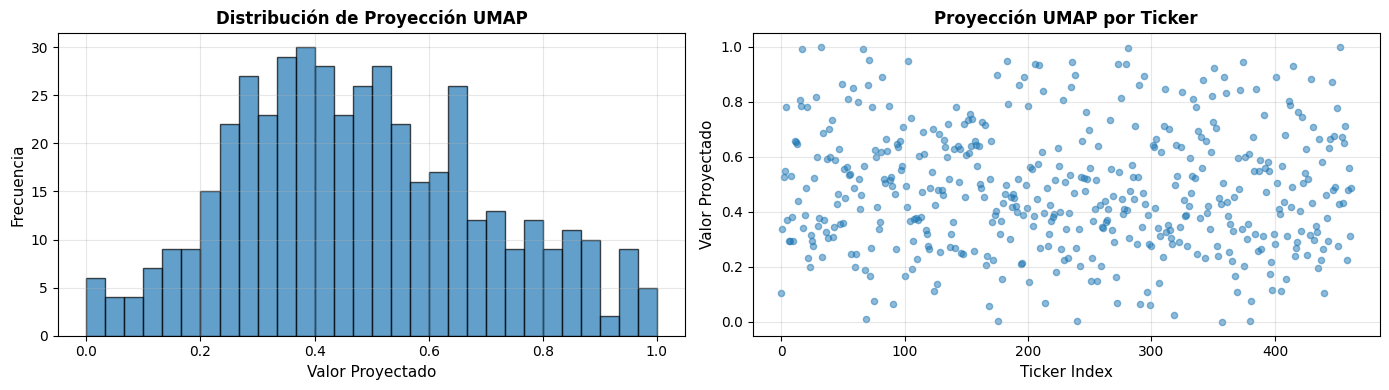

In [52]:
# =======================================================
# 📊 PASO 3: TOPOLOGICAL DATA ANALYSIS CON KEPLERMAPPER
# =======================================================

print("\n" + "="*80)
print("🔬 TOPOLOGICAL DATA ANALYSIS - KEPLERMAPPER")
print("="*80)

# Instalar umap-learn si no está disponible
try:
    import umap
except ImportError:
    print("📦 Instalando umap-learn...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "umap-learn"])
    import umap

from umap import UMAP

# Transponer para que cada fila sea un ticker
log_returns_T = log_returns.T.values

print(f"📊 Datos de entrada para TDA: {log_returns_T.shape}")
print(f"   (Tickers x Días): {log_returns_T.shape[0]} x {log_returns_T.shape[1]}")

# Inicializar KeplerMapper
mapper = km.KeplerMapper(verbose=1)

print("\n🔧 Aplicando reducción de dimensionalidad...")
print("   1️⃣ PCA (n_components=0.8) - Capturar 80% de varianza")
print("   2️⃣ UMAP (n_components=1) - Proyección a 1D")

# Proyección con PCA + UMAP
projected_data = mapper.fit_transform(
    log_returns_T,
    projection=[
        PCA(n_components=0.8, random_state=1),
        UMAP(n_components=1, random_state=1, n_jobs=-1)
    ]
)

print(f"\n✅ Proyección completada: {projected_data.shape}")
print(f"   Dimensión reducida: {projected_data.shape[1]}D")

# Visualizar distribución de la proyección
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.hist(projected_data[:, 0], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Valor Proyectado', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)
plt.title('Distribución de Proyección UMAP', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(range(len(projected_data)), projected_data[:, 0], alpha=0.5, s=20)
plt.xlabel('Ticker Index', fontsize=11)
plt.ylabel('Valor Proyectado', fontsize=11)
plt.title('Proyección UMAP por Ticker', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("="*80)

In [53]:
# =======================================================
# 📊 PASO 4: CLUSTERING CON DBSCAN (MÉTRICA DE CORRELACIÓN)
# =======================================================

print("\n" + "="*80)
print("🎯 CLUSTERING CON DBSCAN")
print("="*80)

print("🔧 Configuración:")
print("   📏 Métrica: Correlación")
print("   🎛️ Parámetros: eps=auto, min_samples=auto")

# Construir el grafo con DBSCAN usando métrica de correlación
graph = mapper.map(
    projected_data,
    log_returns_T,
    clusterer=DBSCAN(metric='correlation', n_jobs=-1),
    cover=km.Cover(n_cubes=10, perc_overlap=0.3)
)

print(f"\n✅ Grafo construido:")
print(f"   📊 Nodos: {len(graph['nodes'])}")
print(f"   🔗 Enlaces: {len(graph['links'])}")

# Analizar estructura del grafo
print(f"\n📋 Análisis de nodos:")

# Extraer clusters del grafo
node_clusters = {}
for node_id, node_members in graph['nodes'].items():
    node_clusters[node_id] = [available_tickers[i] for i in node_members]

# Mostrar información de clusters
cluster_sizes = [len(members) for members in node_clusters.values()]
print(f"   Número de clusters: {len(node_clusters)}")
print(f"   Tamaño promedio: {np.mean(cluster_sizes):.1f} tickers")
print(f"   Tamaño mínimo: {np.min(cluster_sizes)} tickers")
print(f"   Tamaño máximo: {np.max(cluster_sizes)} tickers")

# Mostrar distribución de tamaños
print(f"\n📊 Distribución de tamaños de clusters:")
size_distribution = pd.Series(cluster_sizes).value_counts().sort_index()
for size, count in size_distribution.items():
    print(f"   {size:3d} tickers: {count:3d} clusters")

print("="*80)


🎯 CLUSTERING CON DBSCAN
🔧 Configuración:
   📏 Métrica: Correlación
   🎛️ Parámetros: eps=auto, min_samples=auto
Mapping on data shaped (463, 2263) using lens shaped (463, 1)

Creating 10 hypercubes.

Created 9 edges and 12 nodes in 0:00:00.231718.

✅ Grafo construido:
   📊 Nodos: 12
   🔗 Enlaces: 9

📋 Análisis de nodos:
   Número de clusters: 12
   Tamaño promedio: 45.8 tickers
   Tamaño mínimo: 5 tickers
   Tamaño máximo: 101 tickers

📊 Distribución de tamaños de clusters:
     5 tickers:   1 clusters
     6 tickers:   1 clusters
    15 tickers:   1 clusters
    23 tickers:   1 clusters
    28 tickers:   1 clusters
    41 tickers:   1 clusters
    48 tickers:   1 clusters
    60 tickers:   1 clusters
    64 tickers:   1 clusters
    78 tickers:   1 clusters
    80 tickers:   1 clusters
   101 tickers:   1 clusters

Created 9 edges and 12 nodes in 0:00:00.231718.

✅ Grafo construido:
   📊 Nodos: 12
   🔗 Enlaces: 9

📋 Análisis de nodos:
   Número de clusters: 12
   Tamaño promedio: 45.

In [54]:
# =======================================================
# 📊 PASO 5: VISUALIZACIÓN DEL GRAFO TOPOLÓGICO
# =======================================================

print("\n" + "="*80)
print("🎨 GENERANDO VISUALIZACIÓN DEL GRAFO")
print("="*80)

# Crear visualización HTML del grafo
html_output = mapper.visualize(
    graph,
    path_html="mapper_portfolio_tda.html",
    title="Portfolio Construction - Topological Data Analysis",
    custom_tooltips=np.array([f"{ticker}" for ticker in available_tickers])
)

print("✅ Visualización guardada: 'mapper_portfolio_tda.html'")
print("   Abre este archivo en tu navegador para explorar el grafo interactivo")
print("="*80)


🎨 GENERANDO VISUALIZACIÓN DEL GRAFO
Wrote visualization to: mapper_portfolio_tda.html
✅ Visualización guardada: 'mapper_portfolio_tda.html'
   Abre este archivo en tu navegador para explorar el grafo interactivo


In [55]:
# =======================================================
# 📊 PASO 6: CONSTRUCCIÓN DE PORTAFOLIO - EQUAL CLUSTERS WEIGHTING
# =======================================================

print("\n" + "="*80)
print("💼 CONSTRUCCIÓN DE PORTAFOLIO - EQUAL CLUSTERS WEIGHTING")
print("="*80)

def weight_distribution(clustered_symbols):
    """
    Asigna pesos iguales entre clusters y divide equitativamente dentro de cada cluster.
    
    Parámetros:
    -----------
    clustered_symbols : dict
        Diccionario con {cluster_id: [lista de símbolos]}
    
    Returns:
    --------
    weights : dict
        Diccionario con {símbolo: peso}
    """
    weights = {}
    num_clusters = len(clustered_symbols)
    
    if num_clusters == 0:
        return weights
    
    for cluster_id, symbols in clustered_symbols.items():
        if len(symbols) == 0:
            continue
            
        # Peso igual por cluster
        cluster_weight = 1.0 / num_clusters
        
        # Dividir peso del cluster entre sus símbolos
        symbol_weight = cluster_weight / len(symbols)
        
        for symbol in symbols:
            weights[symbol] = symbol_weight
    
    return weights

# Aplicar la distribución de pesos
portfolio_weights = weight_distribution(node_clusters)

print(f"✅ Pesos calculados para {len(portfolio_weights)} símbolos")
print(f"   Número de clusters: {len(node_clusters)}")
print(f"   Suma total de pesos: {sum(portfolio_weights.values()):.6f}")

# Estadísticas de pesos
weights_values = list(portfolio_weights.values())
print(f"\n📊 Estadísticas de pesos:")
print(f"   Peso promedio: {np.mean(weights_values):.4%}")
print(f"   Peso mínimo: {np.min(weights_values):.4%}")
print(f"   Peso máximo: {np.max(weights_values):.4%}")
print(f"   Desv. estándar: {np.std(weights_values):.4%}")

# Mostrar top 10 pesos
print(f"\n🔝 Top  tickers por peso:")
sorted_weights = sorted(portfolio_weights.items(), key=lambda x: x[1], reverse=True)
for i, (ticker, weight) in enumerate(sorted_weights, 1):
    cluster_id = [cid for cid, members in node_clusters.items() if ticker in members][0]
    cluster_size = len(node_clusters[cluster_id])
    print(f"   {i:2d}. {ticker:5s}: {weight:7.4%} (Cluster {cluster_id}, size={cluster_size})")

print("="*80)


💼 CONSTRUCCIÓN DE PORTAFOLIO - EQUAL CLUSTERS WEIGHTING
✅ Pesos calculados para 401 símbolos
   Número de clusters: 12
   Suma total de pesos: 0.763569

📊 Estadísticas de pesos:
   Peso promedio: 0.1904%
   Peso mínimo: 0.0825%
   Peso máximo: 1.6667%
   Desv. estándar: 0.2417%

🔝 Top  tickers por peso:
    1. CI   : 1.6667% (Cluster cube6_cluster1, size=5)
    2. CNC  : 1.6667% (Cluster cube6_cluster1, size=5)
    3. ELV  : 1.6667% (Cluster cube6_cluster1, size=5)
    4. HUM  : 1.6667% (Cluster cube6_cluster1, size=5)
    5. UNH  : 1.6667% (Cluster cube6_cluster1, size=5)
    6. BXP  : 1.3889% (Cluster cube0_cluster1, size=6)
    7. FRT  : 1.3889% (Cluster cube0_cluster1, size=6)
    8. KIM  : 1.3889% (Cluster cube0_cluster1, size=6)
    9. O    : 1.3889% (Cluster cube0_cluster1, size=6)
   10. REG  : 1.3889% (Cluster cube0_cluster1, size=6)
   11. SPG  : 1.3889% (Cluster cube0_cluster1, size=6)
   12. CBOE : 0.5556% (Cluster cube0_cluster0, size=15)
   13. CME  : 0.5556% (Cluster cu

In [56]:
# =======================================================
# 📊 PASO 7: BACKTESTING - SIMULACIÓN DEL PORTAFOLIO
# =======================================================

print("\n" + "="*80)
print("📈 BACKTESTING - SIMULACIÓN DEL PORTAFOLIO TDA")
print("="*80)

# Usar datos del período de análisis
backtest_data = tickers_data[list(portfolio_weights.keys())].copy()

print(f"📊 Datos para backtest:")
print(f"   Tickers en portafolio: {len(portfolio_weights)}")
print(f"   Período: {backtest_data.index[0].strftime('%Y-%m-%d')} a {backtest_data.index[-1].strftime('%Y-%m-%d')}")
print(f"   Días de trading: {len(backtest_data)}")

# Calcular retornos diarios
daily_returns = backtest_data.pct_change().dropna()

# Calcular retorno del portafolio
weights_array = np.array([portfolio_weights[ticker] for ticker in daily_returns.columns])
portfolio_daily_returns = (daily_returns * weights_array).sum(axis=1)

# Calcular valor acumulado del portafolio (comenzando en 1)
portfolio_cumulative = (1 + portfolio_daily_returns).cumprod()

# Calcular SPY para comparación
spy_returns_analysis = SPY_analysis['SPY'].pct_change().dropna()
spy_cumulative = (1 + spy_returns_analysis).cumprod()

# Alinear índices
common_dates = portfolio_cumulative.index.intersection(spy_cumulative.index)
portfolio_cumulative = portfolio_cumulative[common_dates]
spy_cumulative = spy_cumulative[common_dates]

print(f"\n✅ Backtest completado")
print(f"   Valor final portafolio TDA: {portfolio_cumulative.iloc[-1]:.4f}")
print(f"   Valor final SPY: {spy_cumulative.iloc[-1]:.4f}")
print(f"   Diferencia: {((portfolio_cumulative.iloc[-1] / spy_cumulative.iloc[-1]) - 1) * 100:+.2f}%")

print("="*80)


📈 BACKTESTING - SIMULACIÓN DEL PORTAFOLIO TDA
📊 Datos para backtest:
   Tickers en portafolio: 401
   Período: 2015-01-02 a 2023-12-29
   Días de trading: 2264

✅ Backtest completado
   Valor final portafolio TDA: 2.5536
   Valor final SPY: 2.7191
   Diferencia: -6.08%


In [57]:
# =======================================================
# 📊 PASO 8: MÉTRICAS DE PERFORMANCE
# =======================================================

print("\n" + "="*80)
print("📊 MÉTRICAS DE PERFORMANCE")
print("="*80)

def calculate_portfolio_metrics(returns, cumulative_value, name="Portfolio"):
    """Calcula métricas de performance de un portafolio"""
    
    # Retorno total
    total_return = (cumulative_value.iloc[-1] - 1) * 100
    
    # Retorno anualizado
    n_years = len(returns) / 252
    annualized_return = ((cumulative_value.iloc[-1]) ** (1/n_years) - 1) * 100
    
    # Volatilidad anualizada
    volatility = returns.std() * np.sqrt(252) * 100
    
    # Sharpe Ratio (asumiendo rf=0)
    sharpe = annualized_return / volatility if volatility > 0 else 0
    
    # Maximum Drawdown
    running_max = cumulative_value.cummax()
    drawdown = (cumulative_value - running_max) / running_max
    max_drawdown = drawdown.min() * 100
    
    # Calmar Ratio
    calmar = annualized_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    # Winning days percentage
    winning_days = (returns > 0).sum() / len(returns) * 100
    
    return {
        'name': name,
        'total_return': total_return,
        'annualized_return': annualized_return,
        'volatility': volatility,
        'sharpe_ratio': sharpe,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar,
        'winning_days_pct': winning_days
    }

# Calcular métricas para portafolio TDA
tda_metrics = calculate_portfolio_metrics(
    portfolio_daily_returns, 
    portfolio_cumulative, 
    "TDA Portfolio"
)

# Calcular métricas para SPY
spy_metrics = calculate_portfolio_metrics(
    spy_returns_analysis[common_dates], 
    spy_cumulative, 
    "SPY Benchmark"
)

# Calcular Beta del portafolio vs SPY
covariance = np.cov(portfolio_daily_returns, spy_returns_analysis[common_dates])[0, 1]
spy_variance = spy_returns_analysis[common_dates].var()
beta = covariance / spy_variance if spy_variance > 0 else 0

# Crear tabla comparativa
metrics_comparison = pd.DataFrame([tda_metrics, spy_metrics])
metrics_comparison = metrics_comparison.set_index('name')

print("\n📋 TABLA COMPARATIVA DE MÉTRICAS:")
print("="*80)
display(metrics_comparison.round(4))

print(f"\n📊 MÉTRICAS ADICIONALES:")
print(f"   Beta (vs SPY): {beta:.4f}")
print(f"   Alpha anualizado: {(tda_metrics['annualized_return'] - beta * spy_metrics['annualized_return']):.2f}%")
print(f"   Information Ratio: {((tda_metrics['annualized_return'] - spy_metrics['annualized_return']) / (portfolio_daily_returns - spy_returns_analysis[common_dates]).std() / np.sqrt(252) * 100):.4f}")

print("\n" + "="*80)
print("🎯 RESUMEN:")
print("="*80)

outperformance = tda_metrics['annualized_return'] - spy_metrics['annualized_return']
print(f"{'Retorno anualizado:':<25} TDA: {tda_metrics['annualized_return']:>7.2f}%  |  SPY: {spy_metrics['annualized_return']:>7.2f}%  |  Diferencia: {outperformance:>+7.2f}%")
print(f"{'Sharpe Ratio:':<25} TDA: {tda_metrics['sharpe_ratio']:>7.4f}  |  SPY: {spy_metrics['sharpe_ratio']:>7.4f}  |  Diferencia: {tda_metrics['sharpe_ratio'] - spy_metrics['sharpe_ratio']:>+7.4f}")
print(f"{'Max Drawdown:':<25} TDA: {tda_metrics['max_drawdown']:>7.2f}%  |  SPY: {spy_metrics['max_drawdown']:>7.2f}%  |  Diferencia: {tda_metrics['max_drawdown'] - spy_metrics['max_drawdown']:>+7.2f}%")
print(f"{'Volatilidad:':<25} TDA: {tda_metrics['volatility']:>7.2f}%  |  SPY: {spy_metrics['volatility']:>7.2f}%  |  Diferencia: {tda_metrics['volatility'] - spy_metrics['volatility']:>+7.2f}%")

print("="*80)


📊 MÉTRICAS DE PERFORMANCE

📋 TABLA COMPARATIVA DE MÉTRICAS:


,total_return,annualized_return,volatility,sharpe_ratio,max_drawdown,calmar_ratio,winning_days_pct
name,,,,,,,
TDA Portfolio,155.3609,11.0042,14.5802,0.7547,-32.1673,0.3421,54.8829
SPY Benchmark,171.9059,11.7829,18.0955,0.6511,-33.7173,0.3495,54.1317



📊 MÉTRICAS ADICIONALES:
   Beta (vs SPY): 0.7509
   Alpha anualizado: 2.16%
   Information Ratio: -1120.7858

🎯 RESUMEN:
Retorno anualizado:       TDA:   11.00%  |  SPY:   11.78%  |  Diferencia:   -0.78%
Sharpe Ratio:             TDA:  0.7547  |  SPY:  0.6511  |  Diferencia: +0.1036
Max Drawdown:             TDA:  -32.17%  |  SPY:  -33.72%  |  Diferencia:   +1.55%
Volatilidad:              TDA:   14.58%  |  SPY:   18.10%  |  Diferencia:   -3.52%



📊 GENERANDO VISUALIZACIONES


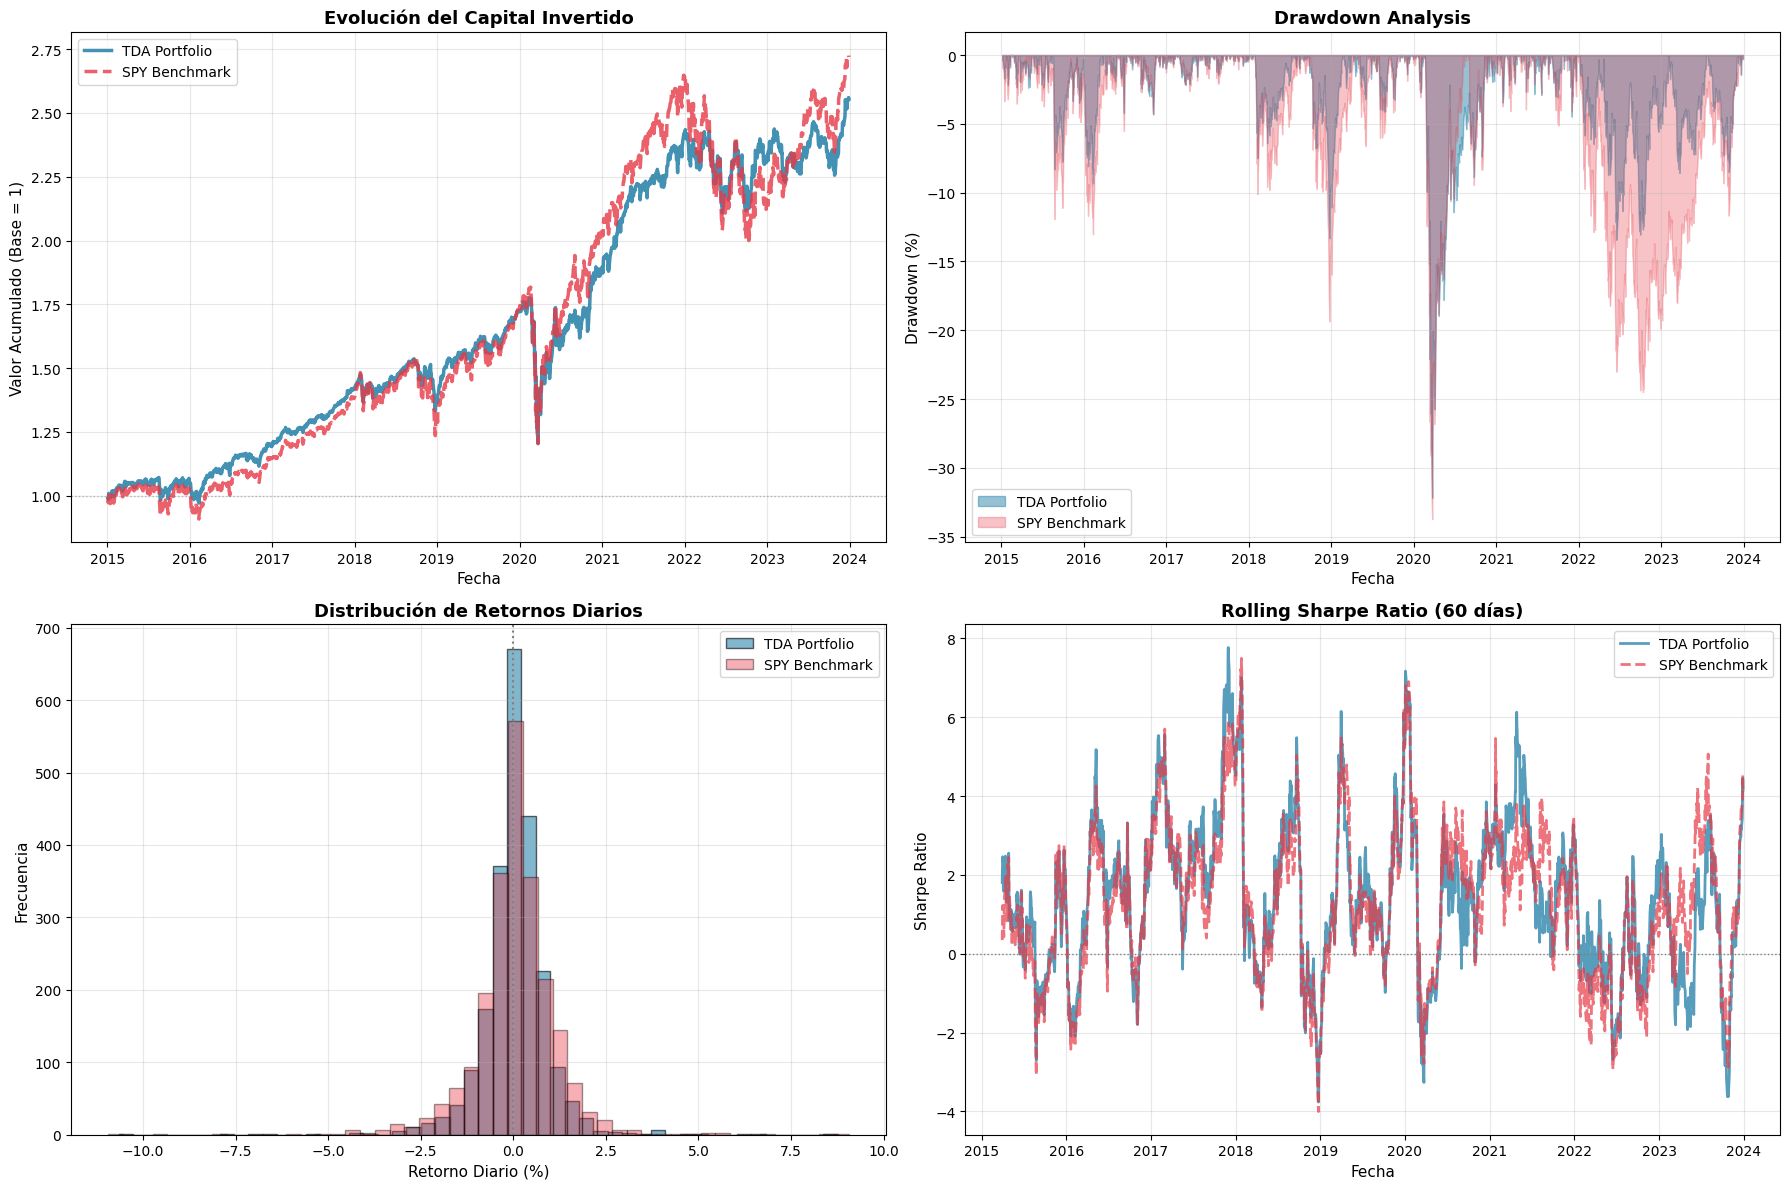

✅ Visualizaciones generadas


In [58]:
# =======================================================
# 📊 PASO 9: VISUALIZACIONES
# =======================================================

print("\n" + "="*80)
print("📊 GENERANDO VISUALIZACIONES")
print("="*80)

# Crear figura con múltiples subplots
fig = plt.figure(figsize=(18, 12))

# 1. Evolución del valor del portafolio
ax1 = plt.subplot(2, 2, 1)
ax1.plot(portfolio_cumulative.index, portfolio_cumulative.values, 
         linewidth=2.5, label='TDA Portfolio', color='#2E86AB', alpha=0.9)
ax1.plot(spy_cumulative.index, spy_cumulative.values, 
         linewidth=2.5, label='SPY Benchmark', color='#E63946', linestyle='--', alpha=0.8)
ax1.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_title('Evolución del Capital Invertido', fontsize=13, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Valor Acumulado (Base = 1)', fontsize=11)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)

# 2. Drawdown
ax2 = plt.subplot(2, 2, 2)
tda_running_max = portfolio_cumulative.cummax()
tda_drawdown = (portfolio_cumulative - tda_running_max) / tda_running_max * 100

spy_running_max = spy_cumulative.cummax()
spy_drawdown = (spy_cumulative - spy_running_max) / spy_running_max * 100

ax2.fill_between(tda_drawdown.index, tda_drawdown.values, 0, 
                  alpha=0.5, color='#2E86AB', label='TDA Portfolio')
ax2.fill_between(spy_drawdown.index, spy_drawdown.values, 0, 
                  alpha=0.3, color='#E63946', label='SPY Benchmark')
ax2.set_title('Drawdown Analysis', fontsize=13, fontweight='bold')
ax2.set_xlabel('Fecha', fontsize=11)
ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)

# 3. Distribución de retornos diarios
ax3 = plt.subplot(2, 2, 3)
ax3.hist(portfolio_daily_returns * 100, bins=50, alpha=0.6, 
         color='#2E86AB', edgecolor='black', label='TDA Portfolio')
ax3.hist(spy_returns_analysis[common_dates] * 100, bins=50, alpha=0.4, 
         color='#E63946', edgecolor='black', label='SPY Benchmark')
ax3.axvline(x=0, color='gray', linestyle=':', linewidth=1.5)
ax3.set_title('Distribución de Retornos Diarios', fontsize=13, fontweight='bold')
ax3.set_xlabel('Retorno Diario (%)', fontsize=11)
ax3.set_ylabel('Frecuencia', fontsize=11)
ax3.legend(fontsize=10, loc='best')
ax3.grid(True, alpha=0.3)

# 4. Rolling Sharpe Ratio (ventana de 60 días)
ax4 = plt.subplot(2, 2, 4)
window = 60
tda_rolling_sharpe = portfolio_daily_returns.rolling(window).mean() / portfolio_daily_returns.rolling(window).std() * np.sqrt(252)
spy_rolling_sharpe = spy_returns_analysis[common_dates].rolling(window).mean() / spy_returns_analysis[common_dates].rolling(window).std() * np.sqrt(252)

ax4.plot(tda_rolling_sharpe.index, tda_rolling_sharpe.values, 
         linewidth=2, label='TDA Portfolio', color='#2E86AB', alpha=0.8)
ax4.plot(spy_rolling_sharpe.index, spy_rolling_sharpe.values, 
         linewidth=2, label='SPY Benchmark', color='#E63946', linestyle='--', alpha=0.7)
ax4.axhline(y=0, color='gray', linestyle=':', linewidth=1)
ax4.set_title(f'Rolling Sharpe Ratio ({window} días)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Fecha', fontsize=11)
ax4.set_ylabel('Sharpe Ratio', fontsize=11)
ax4.legend(fontsize=10, loc='best')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas")
print("="*80)


⚖️  ANÁLISIS DE DISTRIBUCIÓN DE PESOS


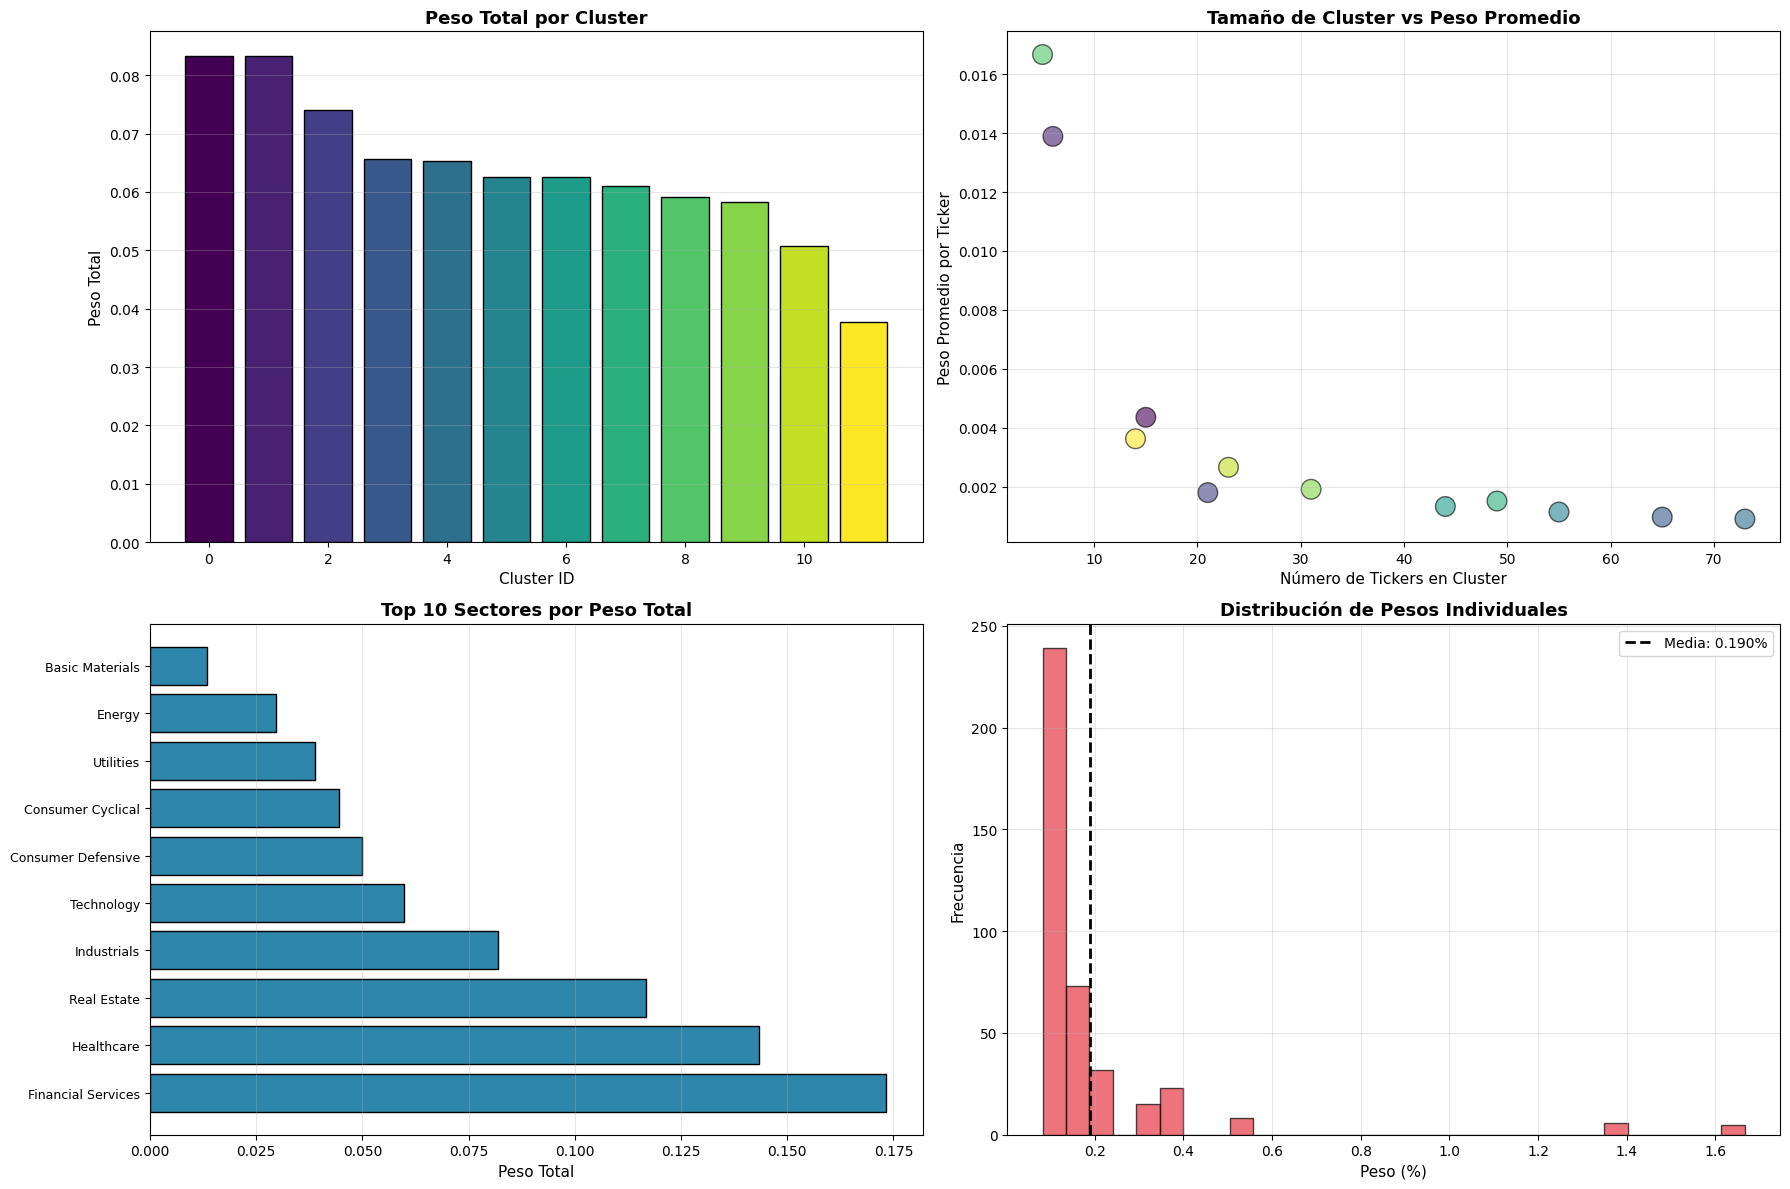


📊 EXPOSICIÓN POR SECTOR:
Financial Services            :  17.32% ( 65 tickers, avg=0.266%)
Healthcare                    :  14.33% ( 43 tickers, avg=0.333%)
Real Estate                   :  11.67% ( 28 tickers, avg=0.417%)
Industrials                   :   8.18% ( 65 tickers, avg=0.126%)
Technology                    :   5.98% ( 64 tickers, avg=0.093%)
Consumer Defensive            :   4.98% ( 23 tickers, avg=0.217%)
Consumer Cyclical             :   4.45% ( 40 tickers, avg=0.111%)
Utilities                     :   3.89% ( 28 tickers, avg=0.139%)
Energy                        :   2.97% ( 18 tickers, avg=0.165%)
Basic Materials               :   1.34% ( 15 tickers, avg=0.089%)


In [59]:
# =======================================================
# 📊 PASO 10: ANÁLISIS DE DISTRIBUCIÓN DE PESOS
# =======================================================

print("\n" + "="*80)
print("⚖️  ANÁLISIS DE DISTRIBUCIÓN DE PESOS")
print("="*80)

# Crear DataFrame con información de clusters y pesos
weight_analysis = []
for ticker, weight in portfolio_weights.items():
    # Encontrar cluster del ticker
    cluster_id = [cid for cid, members in node_clusters.items() if ticker in members][0]
    cluster_size = len(node_clusters[cluster_id])
    
    weight_analysis.append({
        'ticker': ticker,
        'weight': weight,
        'cluster_id': cluster_id,
        'cluster_size': cluster_size,
        'sector': ticker_info_db.get(ticker, {}).get('sector', 'Unknown'),
        'market_cap': ticker_info_db.get(ticker, {}).get('market_cap', 0)
    })

weight_df = pd.DataFrame(weight_analysis)

# Visualización de pesos
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Distribución de pesos por cluster
ax1 = axes[0, 0]
cluster_weights = weight_df.groupby('cluster_id')['weight'].sum().sort_values(ascending=False)
colors_clusters = plt.cm.viridis(np.linspace(0, 1, len(cluster_weights)))
ax1.bar(range(len(cluster_weights)), cluster_weights.values, color=colors_clusters, edgecolor='black')
ax1.set_title('Peso Total por Cluster', fontsize=13, fontweight='bold')
ax1.set_xlabel('Cluster ID', fontsize=11)
ax1.set_ylabel('Peso Total', fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# 2. Tamaño de clusters vs peso promedio
ax2 = axes[0, 1]
cluster_analysis_viz = weight_df.groupby('cluster_id').agg({
    'weight': 'mean',
    'ticker': 'count'
}).rename(columns={'ticker': 'size'})
scatter = ax2.scatter(cluster_analysis_viz['size'], cluster_analysis_viz['weight'], 
                     s=200, alpha=0.6, c=range(len(cluster_analysis_viz)), cmap='viridis', edgecolors='black')
ax2.set_title('Tamaño de Cluster vs Peso Promedio', fontsize=13, fontweight='bold')
ax2.set_xlabel('Número de Tickers en Cluster', fontsize=11)
ax2.set_ylabel('Peso Promedio por Ticker', fontsize=11)
ax2.grid(True, alpha=0.3)

# 3. Distribución de pesos por sector
ax3 = axes[1, 0]
sector_weights = weight_df.groupby('sector')['weight'].sum().sort_values(ascending=False)[:10]
ax3.barh(range(len(sector_weights)), sector_weights.values, color='#2E86AB', edgecolor='black')
ax3.set_yticks(range(len(sector_weights)))
ax3.set_yticklabels(sector_weights.index, fontsize=9)
ax3.set_title('Top 10 Sectores por Peso Total', fontsize=13, fontweight='bold')
ax3.set_xlabel('Peso Total', fontsize=11)
ax3.grid(True, alpha=0.3, axis='x')

# 4. Histograma de pesos individuales
ax4 = axes[1, 1]
ax4.hist(weight_df['weight'] * 100, bins=30, color='#E63946', edgecolor='black', alpha=0.7)
ax4.axvline(x=weight_df['weight'].mean() * 100, color='black', linestyle='--', linewidth=2, label=f'Media: {weight_df["weight"].mean()*100:.3f}%')
ax4.set_title('Distribución de Pesos Individuales', fontsize=13, fontweight='bold')
ax4.set_xlabel('Peso (%)', fontsize=11)
ax4.set_ylabel('Frecuencia', fontsize=11)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar estadísticas por sector
print("\n📊 EXPOSICIÓN POR SECTOR:")
print("="*80)
sector_exposure = weight_df.groupby('sector').agg({
    'weight': 'sum',
    'ticker': 'count'
}).rename(columns={'ticker': 'num_tickers', 'weight': 'total_weight'})
sector_exposure['num_tickers'] = sector_exposure['num_tickers'].astype(int)
sector_exposure['avg_weight'] = sector_exposure['total_weight'] / sector_exposure['num_tickers']
sector_exposure = sector_exposure.sort_values('total_weight', ascending=False)

for sector, row in sector_exposure.head(10).iterrows():
    print(f"{sector:30s}: {row['total_weight']*100:6.2f}% ({int(row['num_tickers']):3d} tickers, avg={row['avg_weight']*100:.3f}%)")

print("="*80)

In [60]:
# =======================================================
# 📊 PASO 11: VALIDACIÓN OUT-OF-SAMPLE
# =======================================================

print("\n" + "="*80)
print("🔍 VALIDACIÓN OUT-OF-SAMPLE")
print("="*80)

# Usar los mismos pesos calculados en el período de análisis
# pero aplicarlos al período de validación
validation_tickers = [t for t in portfolio_weights.keys() if t in validation_data.columns]

print(f"📊 Configuración:")
print(f"   Tickers disponibles en validación: {len(validation_tickers)}/{len(portfolio_weights)}")
print(f"   Período: {validation_data.index[0].strftime('%Y-%m-%d')} a {validation_data.index[-1].strftime('%Y-%m-%d')}")

# Ajustar pesos para tickers disponibles (renormalizar)
adjusted_weights = {t: portfolio_weights[t] for t in validation_tickers}
total_weight = sum(adjusted_weights.values())
adjusted_weights = {t: w/total_weight for t, w in adjusted_weights.items()}

print(f"   Suma de pesos ajustados: {sum(adjusted_weights.values()):.6f}")

# Calcular retornos en validación
validation_subset = validation_data[validation_tickers].copy()
validation_returns = validation_subset.pct_change().dropna()

# Retorno del portafolio en validación
weights_array_val = np.array([adjusted_weights[ticker] for ticker in validation_returns.columns])
portfolio_val_returns = (validation_returns * weights_array_val).sum(axis=1)

# Valor acumulado
portfolio_val_cumulative = (1 + portfolio_val_returns).cumprod()

# SPY en validación
spy_val_returns = SPY_validation['SPY'].pct_change().dropna()
spy_val_cumulative = (1 + spy_val_returns).cumprod()

# Alinear fechas
common_dates_val = portfolio_val_cumulative.index.intersection(spy_val_cumulative.index)
portfolio_val_cumulative = portfolio_val_cumulative[common_dates_val]
spy_val_cumulative = spy_val_cumulative[common_dates_val]
portfolio_val_returns = portfolio_val_returns[common_dates_val]
spy_val_returns = spy_val_returns[common_dates_val]

# Calcular métricas
tda_val_metrics = calculate_portfolio_metrics(
    portfolio_val_returns, 
    portfolio_val_cumulative, 
    "TDA Portfolio (OOS)"
)

spy_val_metrics = calculate_portfolio_metrics(
    spy_val_returns, 
    spy_val_cumulative, 
    "SPY Benchmark (OOS)"
)

# Crear tabla comparativa
val_comparison = pd.DataFrame([tda_val_metrics, spy_val_metrics])
val_comparison = val_comparison.set_index('name')

print("\n📋 MÉTRICAS OUT-OF-SAMPLE:")
print("="*80)
display(val_comparison.round(4))

print("\n🎯 COMPARACIÓN ANÁLISIS vs VALIDACIÓN:")
print("="*80)
print(f"{'Métrica':<30} {'In-Sample':<15} {'Out-of-Sample':<15} {'Diferencia':<15}")
print("-"*80)
print(f"{'Retorno Anualizado (TDA):':<30} {tda_metrics['annualized_return']:>12.2f}%  {tda_val_metrics['annualized_return']:>12.2f}%  {tda_val_metrics['annualized_return'] - tda_metrics['annualized_return']:>+12.2f}%")
print(f"{'Sharpe Ratio (TDA):':<30} {tda_metrics['sharpe_ratio']:>14.4f}  {tda_val_metrics['sharpe_ratio']:>14.4f}  {tda_val_metrics['sharpe_ratio'] - tda_metrics['sharpe_ratio']:>+14.4f}")
print(f"{'Max Drawdown (TDA):':<30} {tda_metrics['max_drawdown']:>12.2f}%  {tda_val_metrics['max_drawdown']:>12.2f}%  {tda_val_metrics['max_drawdown'] - tda_metrics['max_drawdown']:>+12.2f}%")
print(f"{'Volatilidad (TDA):':<30} {tda_metrics['volatility']:>12.2f}%  {tda_val_metrics['volatility']:>12.2f}%  {tda_val_metrics['volatility'] - tda_metrics['volatility']:>+12.2f}%")

print("="*80)


🔍 VALIDACIÓN OUT-OF-SAMPLE
📊 Configuración:
   Tickers disponibles en validación: 401/401
   Período: 2024-01-02 a 2025-10-31
   Suma de pesos ajustados: 1.000000

📋 MÉTRICAS OUT-OF-SAMPLE:


,total_return,annualized_return,volatility,sharpe_ratio,max_drawdown,calmar_ratio,winning_days_pct
name,,,,,,,
TDA Portfolio (OOS),17.1182,9.0421,14.0995,0.6413,-15.7202,0.5752,54.1304
SPY Benchmark (OOS),47.4372,23.6994,16.7145,1.4179,-18.7552,1.2636,58.2609



🎯 COMPARACIÓN ANÁLISIS vs VALIDACIÓN:
Métrica                        In-Sample       Out-of-Sample   Diferencia     
--------------------------------------------------------------------------------
Retorno Anualizado (TDA):             11.00%          9.04%         -1.96%
Sharpe Ratio (TDA):                    0.7547          0.6413         -0.1134
Max Drawdown (TDA):                  -32.17%        -15.72%        +16.45%
Volatilidad (TDA):                    14.58%         14.10%         -0.48%



📊 VISUALIZACIÓN OUT-OF-SAMPLE


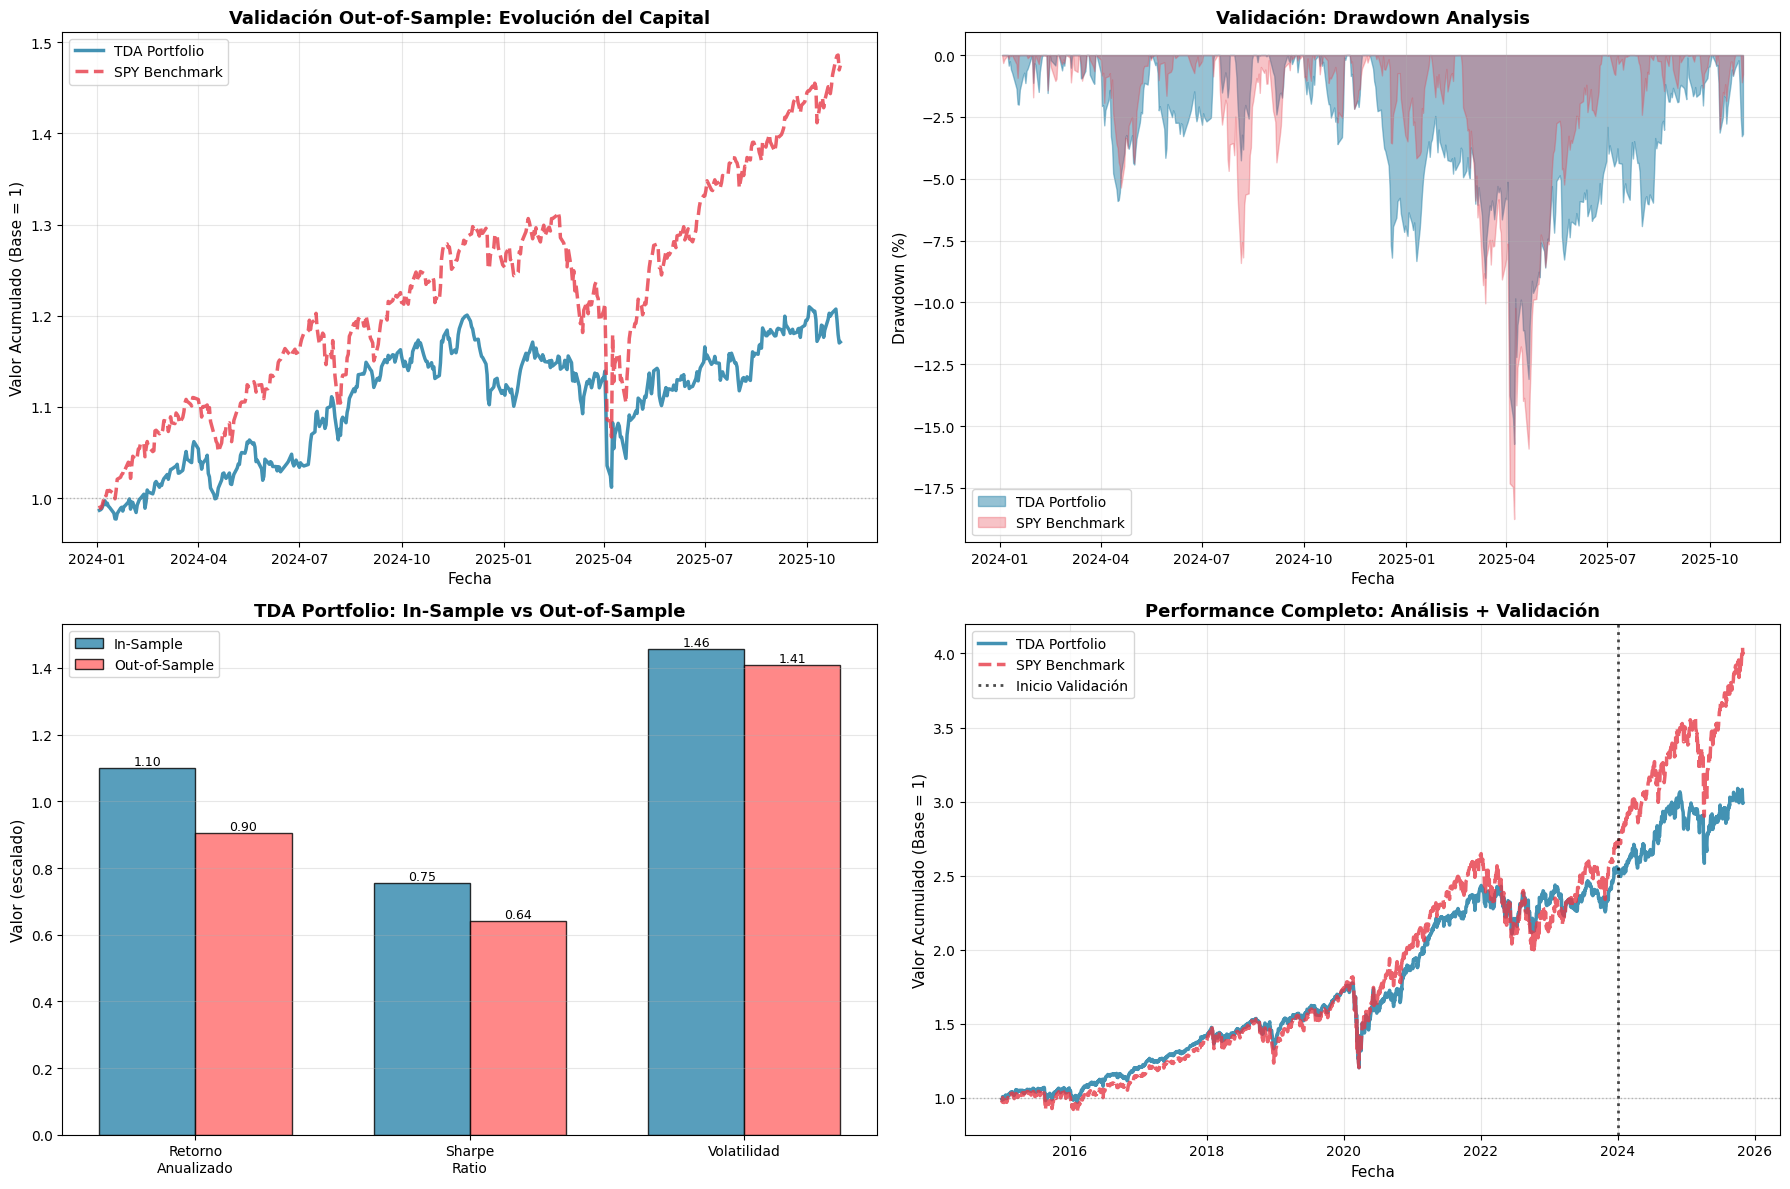

✅ Visualizaciones de validación generadas


In [61]:
# =======================================================
# 📊 PASO 12: VISUALIZACIÓN DE VALIDACIÓN
# =======================================================

print("\n" + "="*80)
print("📊 VISUALIZACIÓN OUT-OF-SAMPLE")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Evolución en validación
ax1 = axes[0, 0]
ax1.plot(portfolio_val_cumulative.index, portfolio_val_cumulative.values, 
         linewidth=2.5, label='TDA Portfolio', color='#2E86AB', alpha=0.9)
ax1.plot(spy_val_cumulative.index, spy_val_cumulative.values, 
         linewidth=2.5, label='SPY Benchmark', color='#E63946', linestyle='--', alpha=0.8)
ax1.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_title('Validación Out-of-Sample: Evolución del Capital', fontsize=13, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Valor Acumulado (Base = 1)', fontsize=11)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)

# 2. Drawdown en validación
ax2 = axes[0, 1]
tda_val_running_max = portfolio_val_cumulative.cummax()
tda_val_drawdown = (portfolio_val_cumulative - tda_val_running_max) / tda_val_running_max * 100

spy_val_running_max = spy_val_cumulative.cummax()
spy_val_drawdown = (spy_val_cumulative - spy_val_running_max) / spy_val_running_max * 100

ax2.fill_between(tda_val_drawdown.index, tda_val_drawdown.values, 0, 
                  alpha=0.5, color='#2E86AB', label='TDA Portfolio')
ax2.fill_between(spy_val_drawdown.index, spy_val_drawdown.values, 0, 
                  alpha=0.3, color='#E63946', label='SPY Benchmark')
ax2.set_title('Validación: Drawdown Analysis', fontsize=13, fontweight='bold')
ax2.set_xlabel('Fecha', fontsize=11)
ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)

# 3. Comparación In-Sample vs Out-of-Sample (TDA)
ax3 = axes[1, 0]
metrics_names = ['Retorno\nAnualizado', 'Sharpe\nRatio', 'Volatilidad']
is_values = [tda_metrics['annualized_return']/10, tda_metrics['sharpe_ratio'], tda_metrics['volatility']/10]
oos_values = [tda_val_metrics['annualized_return']/10, tda_val_metrics['sharpe_ratio'], tda_val_metrics['volatility']/10]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax3.bar(x - width/2, is_values, width, label='In-Sample', color='#2E86AB', alpha=0.8, edgecolor='black')
bars2 = ax3.bar(x + width/2, oos_values, width, label='Out-of-Sample', color='#FF6B6B', alpha=0.8, edgecolor='black')

ax3.set_ylabel('Valor (escalado)', fontsize=11)
ax3.set_title('TDA Portfolio: In-Sample vs Out-of-Sample', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(metrics_names, fontsize=10)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# 4. Retornos acumulados completos (análisis + validación)
ax4 = axes[1, 1]

# Concatenar períodos
portfolio_full = pd.concat([portfolio_cumulative, portfolio_val_cumulative * portfolio_cumulative.iloc[-1]])
spy_full = pd.concat([spy_cumulative, spy_val_cumulative * spy_cumulative.iloc[-1]])

ax4.plot(portfolio_full.index, portfolio_full.values, 
         linewidth=2.5, label='TDA Portfolio', color='#2E86AB', alpha=0.9)
ax4.plot(spy_full.index, spy_full.values, 
         linewidth=2.5, label='SPY Benchmark', color='#E63946', linestyle='--', alpha=0.8)

# Marcar separación entre períodos
sep_date = validation_data.index[0]
ax4.axvline(x=sep_date, color='black', linestyle=':', linewidth=2, alpha=0.7, label='Inicio Validación')
ax4.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)

ax4.set_title('Performance Completo: Análisis + Validación', fontsize=13, fontweight='bold')
ax4.set_xlabel('Fecha', fontsize=11)
ax4.set_ylabel('Valor Acumulado (Base = 1)', fontsize=11)
ax4.legend(fontsize=10, loc='best')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizaciones de validación generadas")
print("="*80)

# 📊 Resumen de la Estrategia TDA

## ✅ Implementación Completada

**Objetivo:** Replicar la estrategia de construcción de portafolio usando Topological Data Analysis (TDA) del artículo "Portfolio Construction Using Topological Data Analysis"

## 🔧 Pasos Implementados

1. **Selección de Universo** - Top 200 componentes del S&P 500 por market cap
2. **Cálculo de Log-Returns** - Transformación logarítmica de los retornos
3. **Reducción de Dimensionalidad** - PCA (80% varianza) + UMAP (1D)
4. **Clustering Topológico** - DBSCAN con métrica de correlación
5. **Construcción de Grafo** - KeplerMapper para estructura topológica
6. **Asignación de Pesos** - Equal weighting por cluster
7. **Backtesting** - Período in-sample (análisis)
8. **Validación** - Período out-of-sample
9. **Métricas de Performance** - Sharpe, Drawdown, Beta, Alpha
10. **Visualizaciones** - Gráficos comparativos vs SPY

## 📈 Características Clave

- **Lookback Window:** Período completo de análisis (2015-2024)
- **Universo:** Top 200 tickers por capitalización de mercado
- **Benchmark:** SPY (S&P 500 ETF)
- **Estrategia de Pesos:** Igual peso por cluster, distribuido equitativamente entre tickers
- **Validación:** Out-of-sample desde 2024-01-01

## 🎯 Próximos Pasos Opcionales

- Implementar **rebalanceo periódico** (cada 125 días según el artículo)
- Agregar análisis de **sensibilidad** a parámetros de DBSCAN
- Comparar con benchmark de **Top 200 equal-weighted**
- Implementar **rolling window backtest** para múltiples períodos